# Feature Selection

## 1) Objective
 

In the last module we used L1 and L2 regularization in order to reduce the complexity of the model. Now, we want to take one more step and check how the features contribute to the model accuracy explictly and based on that, select the features accordingly.

## 2) Calling Libaries

As before, we will use pre-defined custom functions which are stored in a file called ```Auxiliary.py```. 

In [35]:
import sys  
sys.path.insert(1, '../11 Codes')

from Auxiliary import *

In [ ]:
#help('Auxiliary')

<br>

## 3) Loading, Splitting and Scaling the Data

Next, we load the data set, separate ```X``` and ```Y```, scale the data accordingly and split the set into training and test set as ususal.

In [36]:
location = FindMyFile('Diabetes2.csv')

In [37]:
Data = pd.read_csv(location, sep = ';')
Data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,label
0,6,148.0,72.0,35.00,184.42,33.6,0.63,50,diabetes
1,1,85.0,66.0,29.00,75.91,26.6,0.35,31,healthy
2,8,183.0,64.0,31.34,155.87,23.3,0.67,32,diabetes
3,1,89.0,66.0,23.00,94.00,28.1,0.17,21,healthy
4,0,137.0,40.0,35.00,168.00,43.1,2.29,33,diabetes


In [38]:
X    = Data.drop(['label'], axis = 1)
Y    = Data['label']

The data set contains almost 800 data points, i.e. even if we split training and test data in, say 60/40, the number of data points is more than an order of magnitude larger than the number of coefficients.

In [39]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size = 0.40, random_state = 1)

Scaling the data:

In [40]:
scaler       = StandardScaler()

XS_Train     = scaler.fit_transform(X_Train)
XS_Test      = scaler.transform(X_Test)

<br>

## 4) L1 and L2 Logistic Model

Last time we found that the best model was obtained using ```elastic net``` with $\alpha_1 = 0.085$ and $\alpha_2 = 0.850$. This model will serve as reference when benchmarking accuarcy and other quality estimators.<br>
First, we add the intercept to both, the training and the test data set and add dummy variables for Y:

In [41]:
XS_Train_add = sm.add_constant(pd.DataFrame(XS_Train, columns = X.columns))
XS_Test_add  = sm.add_constant(pd.DataFrame(XS_Test, columns  = X.columns))
Ydumm        = pd.get_dummies(Y_Train).reset_index(drop=True)

Now, we run the model using ```elastic net```:

In [42]:
#the model:
my_model = sm.GLM(Ydumm, XS_Train_add, family = sm.families.Binomial())

In [43]:
#the fit:
alpha1 = 0.085
alpha2 = 0.850

result_reg = my_model.fit_regularized(method = 'elastic_net', alpha = alpha1, L1_wt = alpha2)

...and finally evaluate the model as before. 

In [44]:
#evaluation:
Probs  = result_reg.predict(XS_Test_add)
ProbsR = np.round(Probs)
Ypred  = ['diabetes' if p==1 else 'healthy' for p in ProbsR]

In [45]:
acc = 100*sum(Ypred == Y_Test)/len(Y_Test)
print(f"Accuracy is {acc: .2f}%")

Accuracy is  77.92%


Next, we plot the **confusion matrix**:

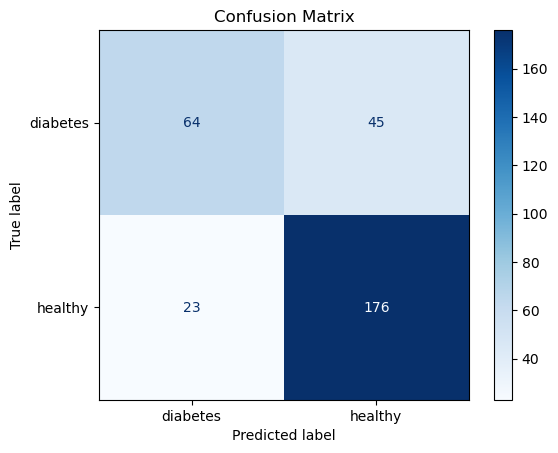

In [46]:
plot_confusion(Y_Test, Ypred,['diabetes', 'healthy'])

and create the **cross-entropy** plot

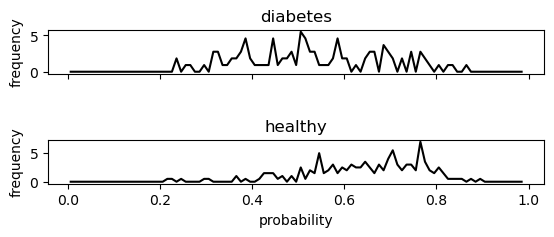

In [47]:
Pmatrix = np.vstack((Probs, 1 - Probs)).transpose()
plot_entropy(Pmatrix, [1 if y=='diabetes' else 0 for y in Y_Test], ['diabetes', 'healthy'], [1, 0])

<br>

## 5) Minimal Model

**5.1) Bootstrapping for $\beta$**

One downside of regularization is that we can't calculate the confidence intervalls for the coefficients $\beta$ in the same straight forward way as before. A simple and relative robust method is bootstrapping (see Module 3 and 10) the dataset and calculating the confidence intervalls for the coefficients $\beta$ via percentiles from the bootstrap results.<br>
Note, that we can run $Nboot = 1000$ fits in a reasonable time because linear models are fast. For that purpose we call ```boot_strap_coeff.py```. The code will run for a few Minutes.

In [48]:
lower, upper = boot_strap_coeff(np.array(XS_Train_add), Ydumm, best_a1 = alpha1, best_a2 = alpha2, Nboot = 1000)

In [49]:
Coefbest = np.array(result_reg.params)
CoefAll  = np.vstack((lower, Coefbest, upper)).transpose()
CoefDf   = pd.DataFrame(CoefAll, columns = ['conf 0.025', 'best', 'conf 0.975'], index = ['const'] + list(X.columns))

In [50]:
#coefficients for best L1 and L2
CoefDf

,conf 0.025,best,conf 0.975
const,-0.496929,-0.339928,-0.188535
Pregnancies,0.000000,0.000000,0.115746
Glucose,0.399908,0.598115,0.759102
BloodPressure,0.000000,0.000000,0.000000
SkinThickness,0.000000,0.000000,0.028725
Insulin,0.000000,0.000000,0.189324
BMI,0.103561,0.282465,0.446421
DiabetesPedigreeFunction,0.000000,0.000000,0.038409
Age,0.000000,0.000703,0.168404


<br>

**5.2) Feature selection via L1 and L2: The Sparse Model**

Last time, we reduced the number of features from nine to six. Now, we take one more step and reduce all those features for which the coefficients are consitent with zero. That leaves only the incercept and ```'Glucose'```and  ```'BMI'```, i.e. three features.

In [51]:
XS_Test_sparse = XS_Test_add[['const', 'Glucose', 'BMI']].copy()
XS_Test_sparse.head()

,const,Glucose,BMI
0,1.0,0.445311,-0.877423
1,1.0,0.940272,-0.863201
2,1.0,-0.445618,-1.019650
3,1.0,-2.029492,0.317280
4,1.0,-0.214636,0.559065


In [52]:
XS_Train_sparse = XS_Train_add[['const', 'Glucose', 'BMI']].copy()
XS_Train_sparse.head()

,const,Glucose,BMI
0,1.0,0.049343,0.103940
1,1.0,-0.280631,1.711100
2,1.0,-0.445618,1.497760
3,1.0,-0.313629,0.160830
4,1.0,-0.379623,0.701291


We run the sparse model **without regularization** first:

In [53]:
my_model_sparse = sm.GLM(Ydumm, XS_Train_sparse, family = sm.families.Binomial())
result_sparse   = my_model_sparse.fit()
result_sparse.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Generalized Linear Model Regression Results                    
===================================================================================
Dep. Variable:     ['diabetes', 'healthy']   No. Observations:                  460
Model:                                 GLM   Df Residuals:                      457
Model Family:                     Binomial   Df Model:                            2
Link Function:                       Logit   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -220.51
Date:                     Sat, 07 Mar 2026   Deviance:                       441.02
Time:                             01:29:39   Pearson chi2:                     429.
No. Iterations:                          5   Pseudo R-squ. (CS):             0.2816
Covariance Type:                 nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.8517      0.122     -6.966      0.000      -1.091      -0.612
Glucose        1.1150      0.133      8.398      0.000       0.855       1.375
BMI            0.7348      0.128      5.719      0.000       0.483       0.987
==============================================================================
"""

The p-values are all below 0.01 which indicates that the remaining features are relevant. If those features which we have removed are not significant, the accuracy of the sparse model should be comparable to the one of the complete model. Therefore, we evaluate the sparse model now:

In [54]:
Probs  = result_sparse.predict(XS_Test_sparse)
ProbsR = np.round(Probs)
Ypred  = ['diabetes' if p==1 else 'healthy' for p in ProbsR]

In [55]:
acc = 100*sum(Ypred == Y_Test)/len(Y_Test)
print(f"Accuracy is {acc: .2f}%")

Accuracy is  75.97%


The accuracy equals the value we obtained when running the complete model (no regularization), which confirms that the features we removed were not relevant.

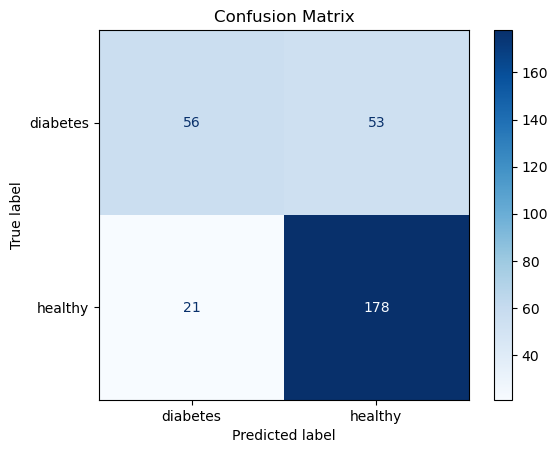

In [56]:
plot_confusion(Y_Test, Ypred,['diabetes', 'healthy'])

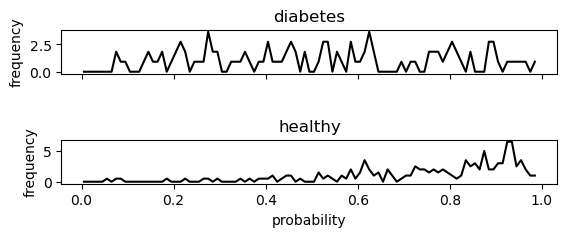

In [57]:
Pmatrix = np.vstack((Probs, 1 - Probs)).transpose()
plot_entropy(Pmatrix, [1 if y=='diabetes' else 0 for y in Y_Test], ['diabetes', 'healthy'], [1, 0])

<br>

Now we run the sparse model **with regularization**:

In [58]:
my_model_sparse   = sm.GLM(Ydumm, XS_Train_sparse, family = sm.families.Binomial())
result_reg_sparse = my_model_sparse.fit_regularized(method = 'elastic_net', alpha = alpha1, L1_wt = alpha2)

In [59]:
Probs  = result_reg_sparse.predict(XS_Test_sparse)
ProbsR = np.round(Probs)
Ypred  = ['diabetes' if p==1 else 'healthy' for p in ProbsR]

In [60]:
acc = 100*sum(Ypred == Y_Test)/len(Y_Test)
print(f"Accuracy is {acc: .2f}%")

Accuracy is  77.92%


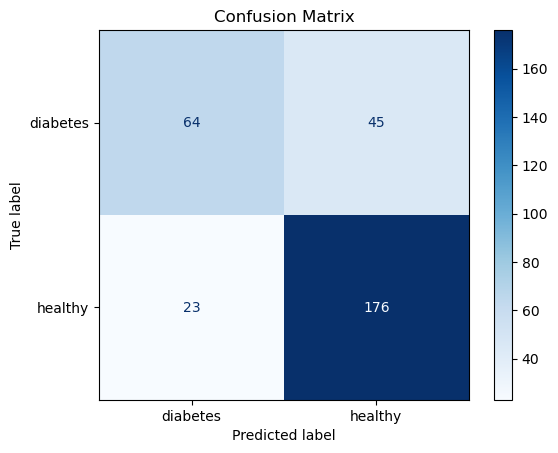

In [61]:
plot_confusion(Y_Test, Ypred,['diabetes', 'healthy'])

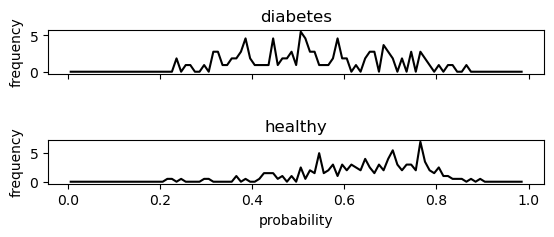

In [62]:
Pmatrix = np.vstack((Probs, 1 - Probs)).transpose()
plot_entropy(Pmatrix, [1 if y=='diabetes' else 0 for y in Y_Test], ['diabetes', 'healthy'], [1, 0])

In [63]:
lower, upper = boot_strap_coeff(np.array(XS_Train_sparse), Ydumm, best_a1 = alpha1, best_a2 = alpha2, Nboot = 1000)

In [64]:
Coefbest = np.array(result_reg_sparse.params)
CoefAll  = np.vstack((lower, Coefbest, upper)).transpose()
CoefDf   = pd.DataFrame(CoefAll, columns = ['conf 0.025', 'best', 'conf 0.975'], index = list(XS_Train_sparse.columns))

In [65]:
CoefDf

,conf 0.025,best,conf 0.975
const,-0.511633,-0.339920,-0.186220
Glucose,0.423664,0.598282,0.759872
BMI,0.104585,0.282437,0.432805


<br>

**5.3) Feature selection via p-values**

Thanks to L1 and L2 it turned out that only the intercept and ```'Glucose'```, ```'BMI'``` and ```'Age'``` are relevant. We excluded the other features via the confidence intervals of the coefficients. However, for that purpose, we needed to bootstrap the model. Maybe we end up with the same result if we select features via the p-values of the coefficents.<br>
Therefore, we run the standard complete model again and check the p-values.

In [66]:
my_model = sm.GLM(Ydumm, XS_Train_add, family = sm.families.Binomial())
result   = my_model.fit()

In [67]:
result.pvalues

const                       1.367712e-12
Pregnancies                 7.415132e-02
Glucose                     8.237812e-12
BloodPressure               8.401696e-02
SkinThickness               6.476258e-01
Insulin                     5.615383e-01
BMI                         1.887106e-07
DiabetesPedigreeFunction    3.558123e-01
Age                         1.980355e-02
dtype: float64

We see that the coefficients for the intercept, ```'Glucose'```, ```'BMI'``` and ```'Age'``` have the smallest p-values - which is remarkably consitent with our earlier findings!<br>
In order to understand better how each feature contributes to the model accuracy, we iteratively remove the feature for which the coefficient has the highest p-value, calculate the accurcy of the model and then repeat.

In [68]:
Nparam   = len(result.pvalues)
Accur    = np.zeros((Nparam+1,))
Param    = [None]*Nparam
Param[0] = 'none'
LenYTest = len(Y_Test)       

XTrain = XS_Train_add.copy()
XTest  = XS_Test_add.copy()

In [69]:
for i in range(Nparam-1):
    my_model = sm.GLM(Ydumm, XTrain, family = sm.families.Binomial())
    result_i = my_model.fit()

    # calculating accuracy
    Probs    = result_i.predict(XTest)
    ProbsR   = np.round(Probs)
    Ypred    = ['diabetes' if p==1 else 'healthy' for p in ProbsR]

    Accur[i] = 100*sum(Ypred == Y_Test)/LenYTest 

    #finding feature for which the coefficient has the highest p-value
    idx_drop = np.argmax(result_i.pvalues)
    todrop   = XTrain.columns[idx_drop] 

    Param[i+1] = todrop

    #removing the corresponding feature
    XTrain   = XTrain.drop(todrop, axis = 1)
    XTest    = XTest.drop(todrop, axis = 1)

#check which parameter is left:
left = list(set(XS_Train_add.columns)-set(Param[1:]))

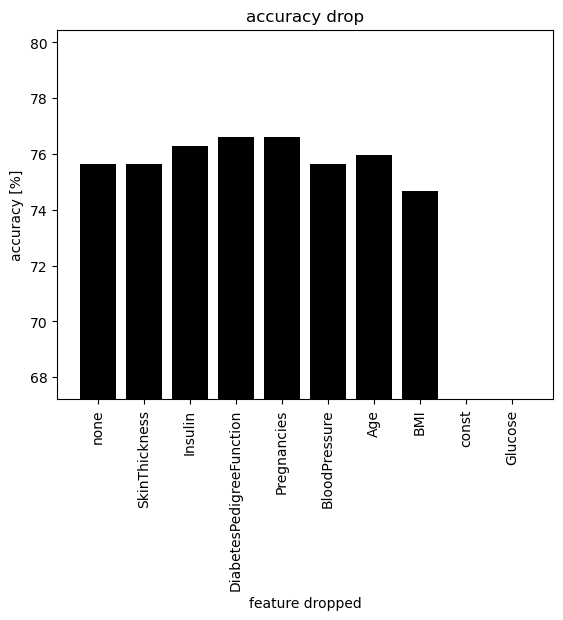

In [70]:
plt.bar(Param + left, Accur, color = 'k')
plt.title('accuracy drop')
plt.xlabel('feature dropped')
plt.ylabel('accuracy [%]')
plt.xticks(rotation = 90)
plt.ylim([np.min(Accur[:-2])*0.9, np.max(Accur)*1.05])
plt.show()

Interestingly, the accuracy increases slightly if we drop the first features. The reason for that is that the model becomes less ambiguous when irrelevant features get removed. The accuracy begins to drop once we remove the features ```BloodPressure```, ```'Age'```, ```'BMI'```, intercept and ```'Glucose'``` in that order. These were the most relevant features according to the sparse model we found via L1 and L2 regularization in module 10 - again a nice consistency.<br> 
Thus, we run the same selection process with the regularization model.

In [71]:
Accur    = np.zeros((Nparam + 1,))
Param    = [None]*Nparam
Param[0] = 'none'

XTrain = XS_Train_add.copy()
XTest  = XS_Test_add.copy()

In [72]:
for i in range(Nparam-1):
    my_model_i   = sm.GLM(Ydumm, XTrain, family = sm.families.Binomial())
    result_reg_i = my_model_i.fit_regularized(method = 'elastic_net', alpha = alpha1, L1_wt = alpha2)

    Probs        = result_reg_i.predict(XTest)
    ProbsR       = np.round(Probs)
    Ypred        = ['diabetes' if p==1 else 'healthy' for p in ProbsR]

    Accur[i]     = 100*sum(Ypred == Y_Test)/LenYTest 

    idx_drop     = np.argmin(abs(np.array(result_reg_i.params)))
    todrop       = XTrain.columns[idx_drop] 

    Param[i+1]   = todrop

    XTrain       = XTrain.drop(todrop, axis = 1)
    XTest        = XTest.drop(todrop, axis = 1)

#check which parameter is left:
left = list(set(XS_Train_add.columns)-set(Param[1:]))

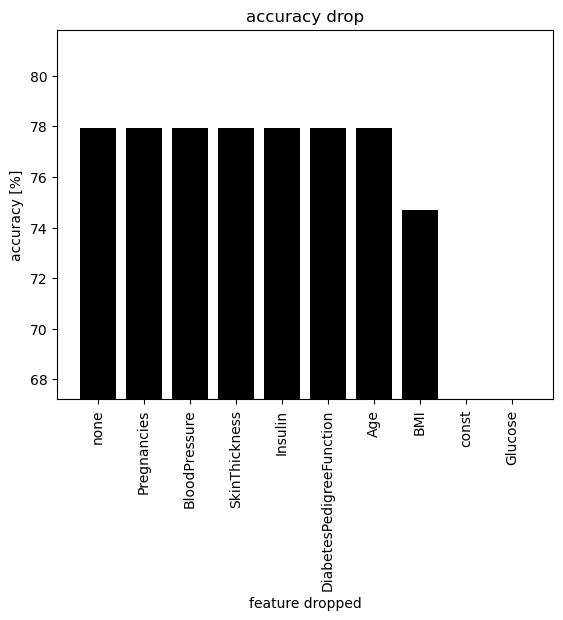

In [73]:
plt.bar(Param + left, Accur, color = 'k')
plt.title('accuracy drop')
plt.xlabel('feature dropped')
plt.ylabel('accuracy [%]')
plt.xticks(rotation = 90)
plt.ylim([np.min(Accur[:-2])*0.9, np.max(Accur)*1.05])
plt.show()

Here the situation is even more clear: the accuracy remains until we drop ```BMI``` and therefore the **relevant features are ```'BMI'```, intercept and ```'Glucose'```**, again consitent with the p-values found earlier.

<br>

**5.4 PCA**

We used PCA for dimensionality reduction earlier. Thus, we have reasons to belief that we should be able to reduce the complexity of the model by considering only those directions for which we find significantly larger eigenvalues.

We want to make sure that we start with the original, scaled data set: 

In [74]:
XS_Train = pd.DataFrame(XS_Train, columns = X.columns)
XS_Test  = pd.DataFrame(XS_Test, columns = X.columns)
N        = len(XS_Train.columns)

We run

And we run PCA as before:

In [75]:
pca = PCA(n_components = N).fit(XS_Train) 

In [76]:
eigenVec = pca.components_
eigenVal = pca.explained_variance_
eigenX   = pca.transform(XS_Train)

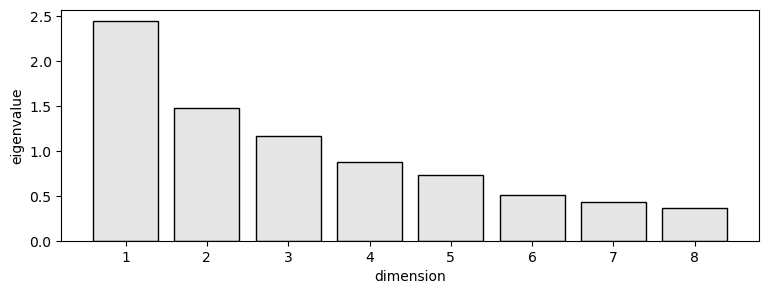

In [77]:
xplot    = np.arange(1, N+1)

fig = plt.figure(figsize  =(N+1, 3))
plt.bar(xplot, eigenVal, color = (0.9, 0.9, 0.9), edgecolor = 'black')
plt.xlabel('dimension')
plt.ylabel('eigenvalue')
#plt.yscale('log')
plt.xticks(xplot)
plt.show()

Unfortunately, the eigenvalue spectrum does not exhibit the "elbow" like structure we were hoping for. There are no directions in the eigenspace which contain most of the information. 

In [78]:
VarExplained = 100*np.cumsum(eigenVal)/np.sum(eigenVal)

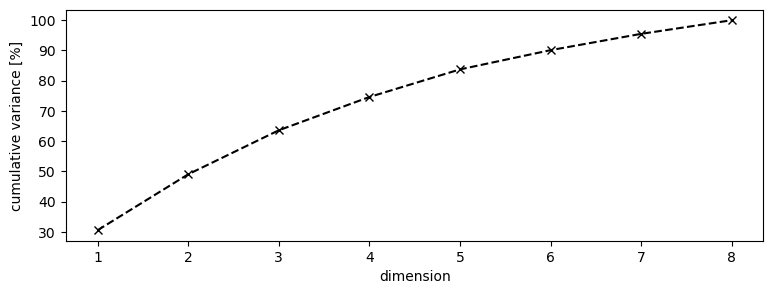

In [79]:
xplot = np.arange(1, N+1)

fig = plt.figure(figsize  =(N+1, 3))
plt.plot(xplot, VarExplained, 'x--', color = 'black')
plt.xlabel('dimension')
plt.ylabel('cumulative variance [%]')
#plt.yscale('log')
plt.xticks(xplot)
plt.show()

Also selecting different combinations of the PC axes does not show a good separation of the data points for any combination:

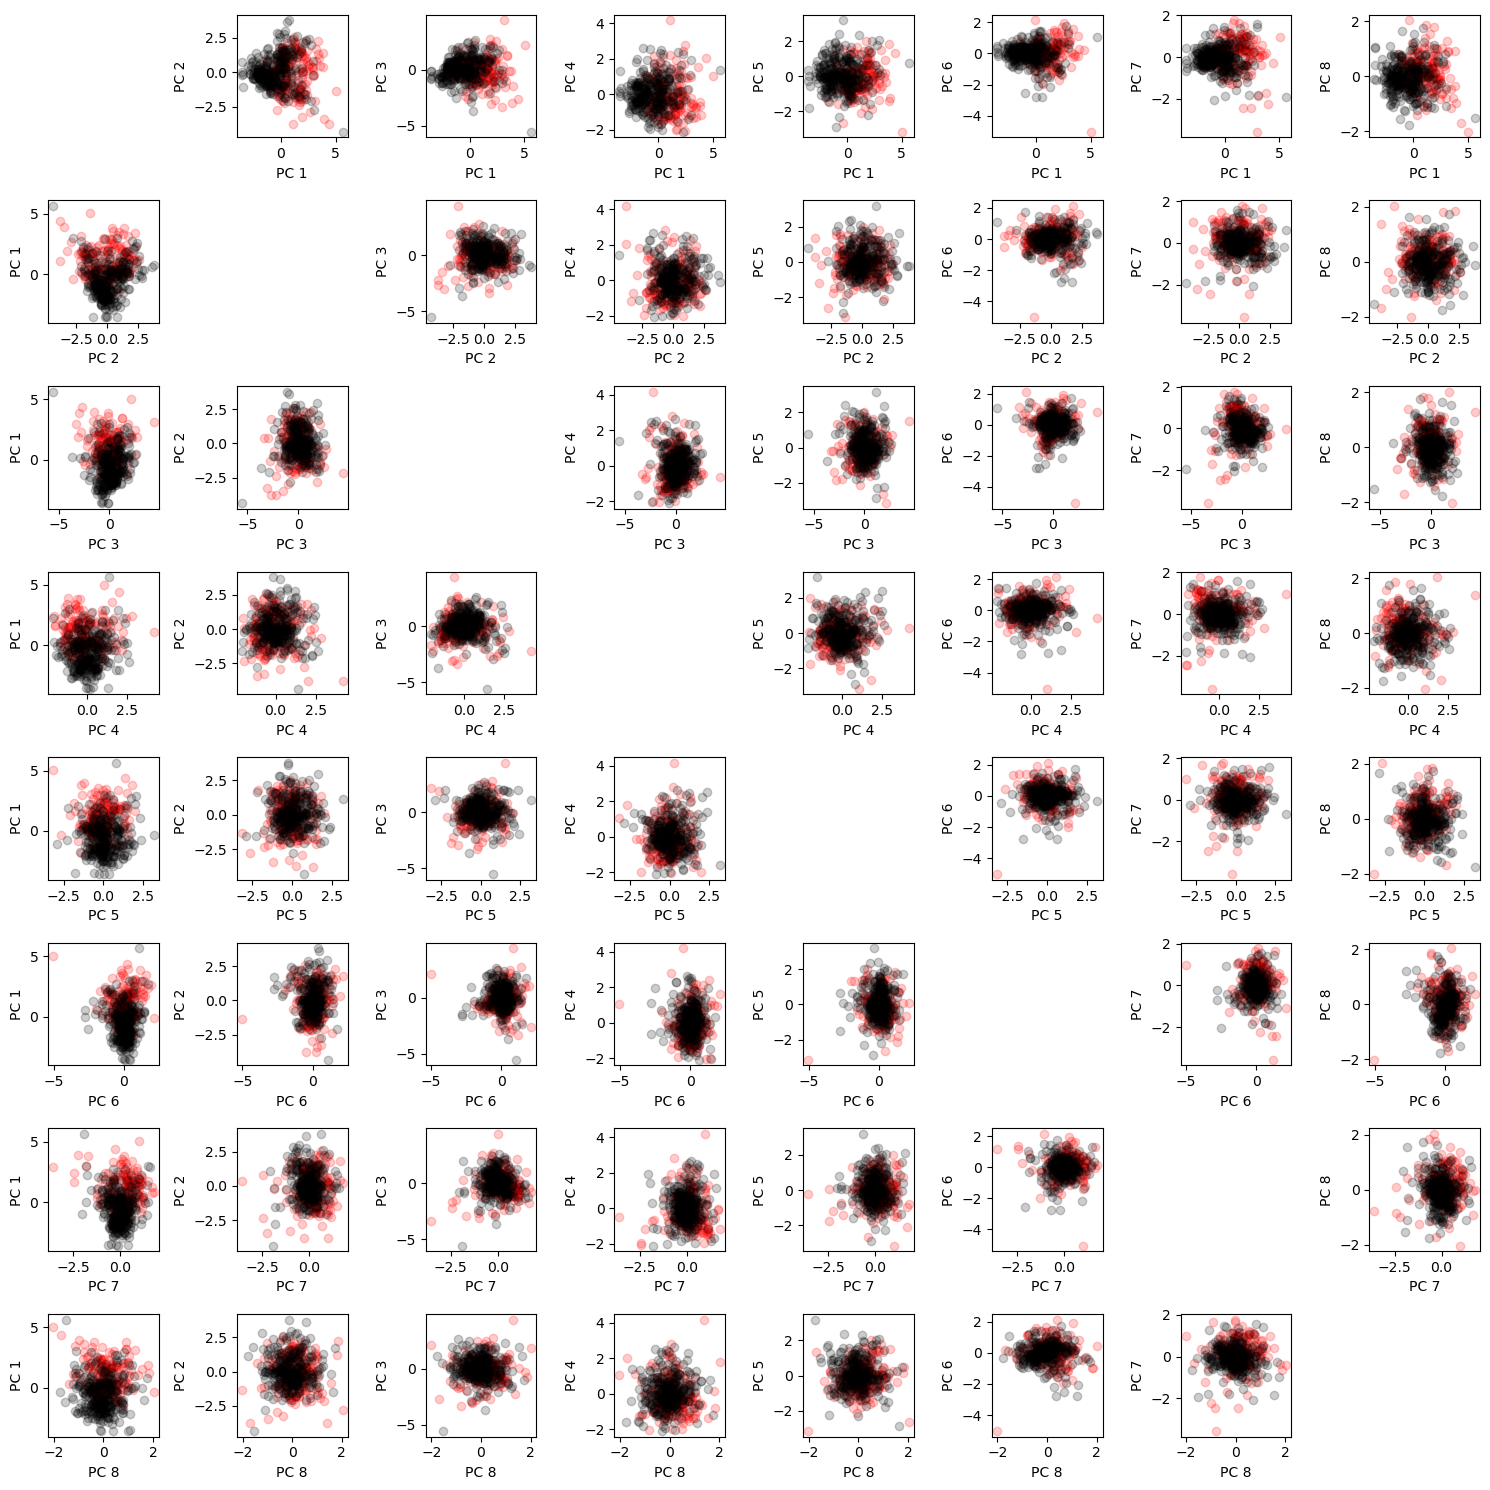

In [80]:
_, axes     = plt.subplots(N, N, figsize=(15, 15))
idxdiabetes = np.array(Y_Train == 'diabetes')
idxhealthy  = np.array(Y_Train == 'healthy')

for i in range(N):
    for j in range(N):
        if i != j:
            current_ax = axes[i, j]
            x          = eigenX[:,i]
            y          = eigenX[:,j]
            current_ax.scatter(x[idxdiabetes], y[idxdiabetes], c = 'red', alpha = .2)
            current_ax.scatter(x[idxhealthy], y[idxhealthy], c = 'black', alpha = .2)
            current_ax.set_xlabel('PC ' + str(i+1))
            current_ax.set_ylabel('PC ' + str(j+1))
        else:
            axes[i, j].axis('off')
plt.tight_layout()
plt.show()

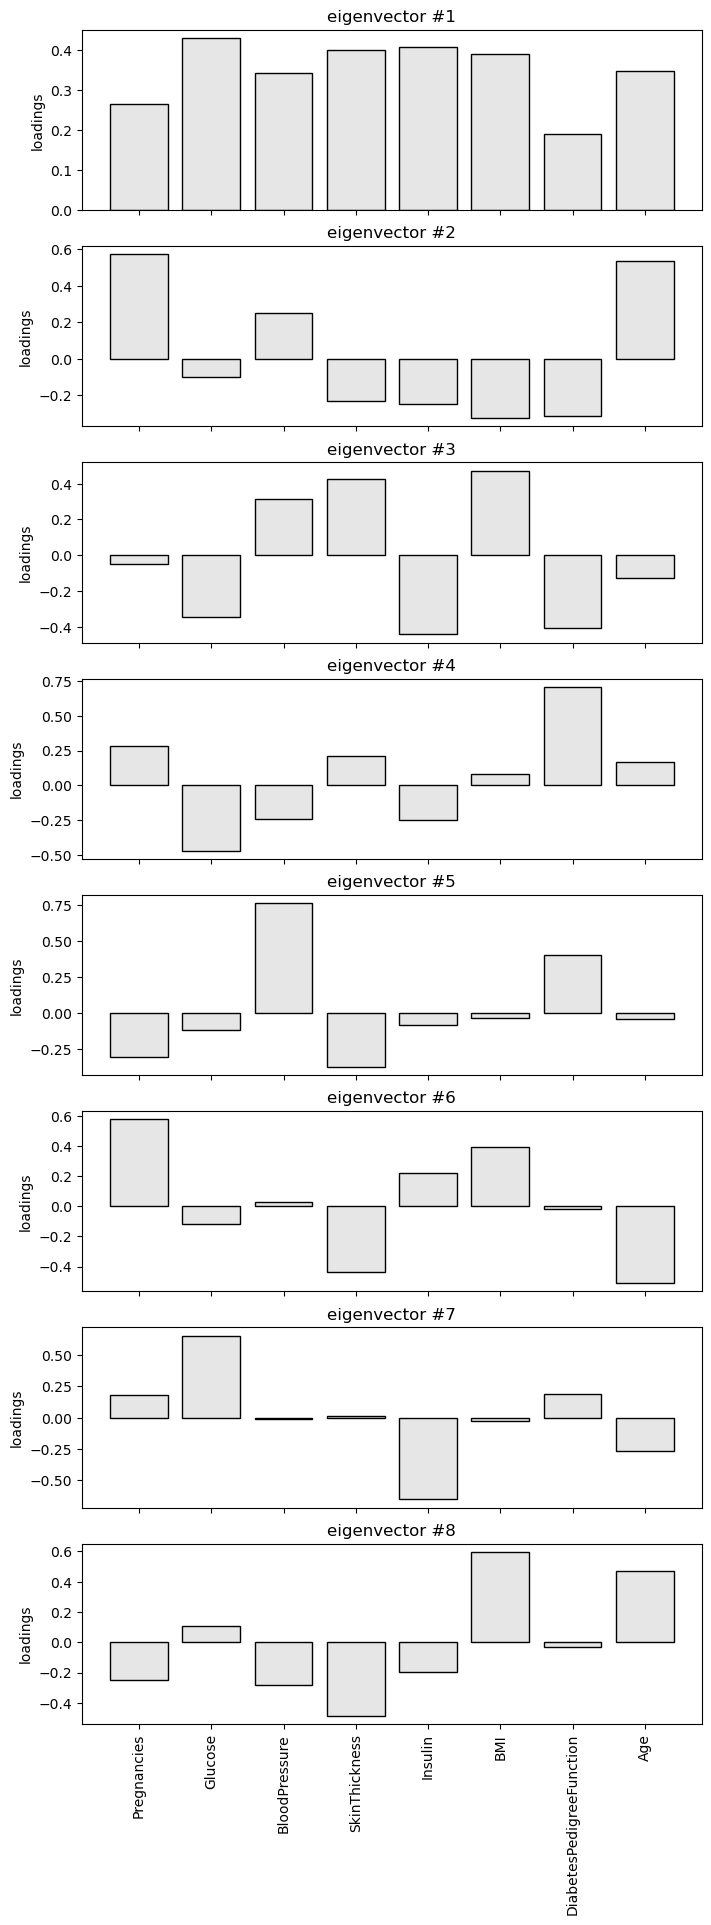

In [81]:
_, axes = plt.subplots(N, 1, figsize=(N, 22), sharex=True)
for i in range(N):
    current_ax = axes[i]
    current_ax.bar(xplot, eigenVec[i,:], color = (0.9, 0.9, 0.9), edgecolor = 'black')
    current_ax.set_ylabel('loadings')
    current_ax.set_xticks(xplot,X.columns, rotation = 90)
    current_ax.set_title('eigenvector #' + str(i+1))
plt.show()

Therefore, PCA does not seem to be a good choice in this particular case.<br>
Thus, we found that the features which are relevant are **```'BMI'```, intercept and ```'Glucose'```**, but not via PCA, but via L1 and L2 and "leave one out".